# Лабораторная работа №5.  Цифровой спектральный анализ.

Лаборатория цифровой обработки сигналов, МФТИ

В названии файла заменить `familyname` на свою фамилию. 

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from scipy.io import wavfile
from astropy.timeseries import LombScargle


In [2]:
def dtft(x, M=None):
    """
    Функция вычисляет значения ДВПФ в M точках на отрезке
    по оси нормированных частот [-0.5; 0.5]

    Parameters
    ----------
    x : complex
        входная последовательность отсчетов, первый отсчет при k=0
    M : int
        колличество точек на отрезке [-0.5; 0.5]

    Returns
    -------
    float
        значения оси нормированных частот,
        соотвествующих вычисленным значениям
        спектральной функции
    complex
        значения спектральной функции
    """
    if M is None:
        M=len(x)
    return (np.fft.fftshift(np.fft.fftfreq(M, d=1)), np.fft.fftshift(np.fft.fft(x, M)))

def oscilloscope_file_read(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.closed

    figsize=[8, 4]

    # dt
    val, unit = str1[1].replace(',', '.').split(' ')[3:5]
    val=float(val)
    if unit=='uS':
        val*=1e-6
    elif unit=='nS':
        val*=1e-9
    elif unit=='mS':
        val*=1e-3
    fs = int(1.0 / val)

    #Voltage step
    val, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(val)
    if unit=='mV':
        dv*=1e-3


    # Zero level
    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev


In [3]:
# %matplotlib inline


In [4]:
%matplotlib widget


# Модуль 1. Окна в спектральном анализе методом ДПФ, алгоритмы вычисления ДПФ.

## Задача 1.1. Окна в спектральном анализе

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, кГц | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 40 |

Получите с помощью сумматора на резисторах сигнал суммы синусоиды с частотой $f_0$ и синусоиды с частотой $f_1=f_0+170 \text{ Гц}$, амплитуды которых отличаются 4 раза (размах 1 В и 4 В). Получите 1000 последовательных выборок сигнала с частотой дискретизации 100 кГц. Постройте график спектра сигнала при его взвешивании различными окнами (прямоугольное, Ханна, с плокоской вершиной). Различимы ли синусоиды? Объясните результаты. 



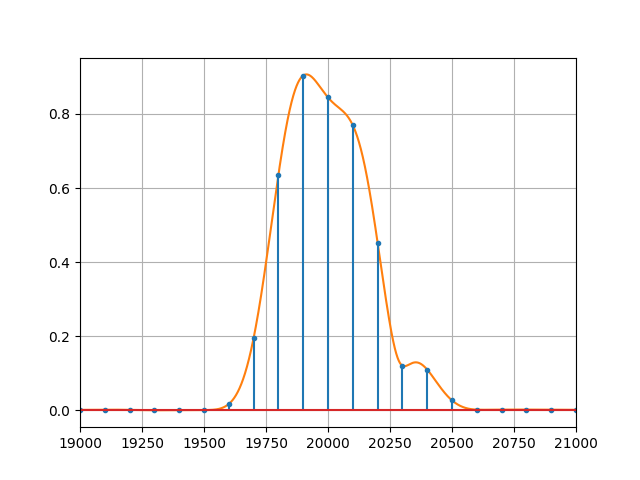

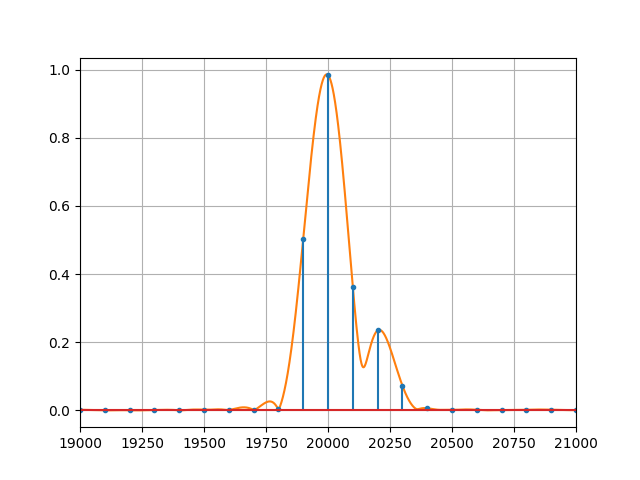

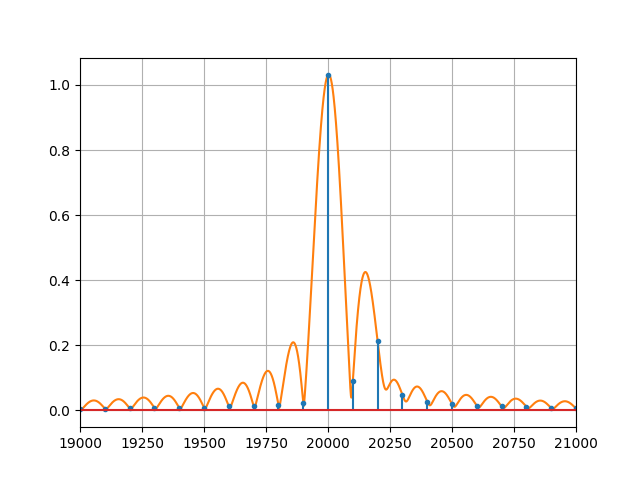

In [5]:
# Чтение сигнала из файла
fs, x = oscilloscope_file_read(file='Data/gosha/gosha1.1.txt', const_level=0)

def plot_spectrum(x, fs, window='boxcar', plot_dtft=True, plot_dft=True, M=2048, f_lim=None, w_normalisation=False, close_input=False):
    if close_input:
        x = x - np.mean(x)
    w = signal.get_window(window, Nx=len(x), fftbins=True)
    x = x * w
    w_sum = sum(w)/2
    plt.figure()
    if plot_dtft:
        nu, X = dtft(x, M)
        if w_normalisation:
            X/=w_sum
        plt.plot(nu * fs, abs(X), color="C1")
    if plot_dft:
        nu, X = dtft(x)
        if w_normalisation:
            X/=w_sum
        plt.stem(nu * fs, abs(X), markerfmt=".")
    if not(f_lim is None):
        plt.xlim(f_lim)
    plt.grid()
    plt.show()

# 'flattop', 'hann', 'boxcar'
#plot_spectrum(x, fs,  window='flattop', plot_dtft=True, plot_dft=True, M=2**18, f_lim=None, w_normalisation=False, close_input=True)
plot_spectrum(x, fs,  window='flattop', plot_dtft=True, plot_dft=True, M=2**18, f_lim=(19000, 21000), w_normalisation=True, close_input=True)
plot_spectrum(x, fs,  window='hann', plot_dtft=True, plot_dft=True, M=2**18, f_lim=(19000, 21000), w_normalisation=True, close_input=True)
plot_spectrum(x, fs,  window='boxcar', plot_dtft=True, plot_dft=True, M=2**18, f_lim=(19000, 21000), w_normalisation=True, close_input=True)


В данном случае для любого из примененных окон по отсчётам ДПФ пики неразличимы. Хотя в случае применения прямоугольного окна дополнением нулевыми отсчетами возможно добиться различимости. 

Неразличимость в случае применения окна flattop связана в первую очередь с шириной его главного лепестка, а в случае применения прямоугольного окна с высокоми боковыми лепестками (с учётом разницы в амплитудах сравниваемых пиков). В случае окна Ханна неразличимость обеспечивают оба этих фактора в сопоставимой мере.

## Задача 1.2*. Алгоритмы вычисления ДПФ.
1) Вычислить 2048-точечное ДПФ для последовательности отсчетов $x[k]$ из задачи 1.1, используя
* а) матричную форму ДПФ,
* б) быстрое преобразование Фурье.

Сравнить результаты.

2) Написать программу вычисления одного отсчета ДПФ по алгоритму Герцеля. Сравнить результаты вычислений с БПФ для любых трех значений $n$.

---

**Алгоритм Герцеля**

1. Для $m=0,\,1,\, \dots,\, N-1$ определяем

$${{V}_{n}}[m]=x[m]+2\cos (2\pi n/N){{V}_{n}}[m-1]-{{V}_{n}}[m-2],\quad 0\le m\le N-1,$$

2. Вычисляем $X[n]$ (при $m=N-1$):

$$X[n]={{\left. {{y}_{n}}[m] \right|}_{m=N-1}}={{\left. \left( W_{N}^{-n}{{V}_{n}}[m]-{{V}_{n}}[m-1] \right) \right|}_{m=N-1}}.$$
$$V_n[-1]=V_n [-2] = 0$$

---



In [6]:
N = 2048
fs, y = oscilloscope_file_read(file='Data/gosha/gosha1.1.txt', const_level=0)
x = np.zeros(N)
x[0:len(y)] = y


In [7]:
from scipy.linalg import dft
W = dft(N)
Xn_matrix = W @ x


In [8]:
Xn_fft = np.fft.fft(x, N)
print("Максимальная ошибка (БПФ vs матричная форма ДПФ):", max(abs(Xn_matrix - Xn_fft)))


Максимальная ошибка (БПФ vs матричная форма ДПФ): 6.865115066496416e-11


In [9]:
def w(n, k, N):
    return np.exp(-2j*np.pi*n*k/N)

def goertzel(x, k, N):
    coeff = 2 * np.cos(2 * np.pi * k/N)
    V_prev = 0
    V_prev2 = 0

    for m in range(N):
        V = x[m] + coeff * V_prev - V_prev2
        V_prev2 = V_prev
        V_prev = V

    return w(m, k, N) * V_prev - V_prev2


In [10]:
for n in np.random.randint(low=0, high=N, size=3):
    print (f"n={n}:", np.allclose(Xn_matrix[n], goertzel(x, n, N), atol=1e-13))
    print("GOERTZEL:", goertzel(x, n, N))
    print ("FFT:     ", Xn_fft[n])


n=582: True
GOERTZEL: (-0.5571264294729932-0.7345805700311865j)
FFT:      (-0.5571264294731313-0.734580570031441j)
n=1077: True
GOERTZEL: (0.11018168667373714+0.0016397162718859905j)
FFT:      (0.11018168667376427+0.0016397162718357339j)
n=847: True
GOERTZEL: (-1.309392019208766+0.6264163017260042j)
FFT:      (-1.3093920192086186+0.6264163017262472j)


# Модуль 2. Кратковременное дискретное преобразование Фурье

## Задача 2.1. Кратковременный спектральный анализ wav файла.

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| **Имя файла** | major-scale-piano.wav | xylophone1.wav | xylophone9.wav | glockenspiel1.wav | flute.wav | glockenspiel2.wav | major-scale-piano.wav | xylophone1.wav | xylophone9.wav | glockenspiel1.wav | flute.wav | glockenspiel2.wav | major-scale-piano.wav | xylophone1.wav | xylophone9.wav | glockenspiel1.wav | flute.wav | glockenspiel2.wav | major-scale-piano.wav | xylophone1.wav |


Вычислите с помощью Python кратковременное дискретное преобразование Фурье (STFT) для отсчетов сигнала, содержащихся в аудиофайле из таблицы. Изобразите спектрограмму сигнала. Длину окна $M$, тип оконной функции, число точек в перекрытии $L$, масштабы осей и размерность ДПФ $N_\text{FFT}$ самостоятельно подберите так, чтобы можно было выделить гармонические компоненты в сигнале. Ответьте на следующие вопросы.

1) Какие выводы можно сделать о составе данного сигнала по спектрограмме?  

2) Чему равны длина окна и размер перекрытия в секундах? Как это соотносится с графиком?

3) Какое разрешение по времени и какое по частоте для данной спектрограммы?

4) Какие изменения можно наблюдать в спектрограмме, если изменяется:

* а) тип оконной функции,
* б) длина окна $M$,
* в) размерность ДПФ $N_\text{FFT}$ за счет дополнения нулевыми отсчетами?










1. Видно, что было по ксилофону было совершено 4 удара: 880 Гц (ля второй октавы; длительность 0.0-1.9 с), 1320 Гц (ми третьей октавы; 0.9-4.7 с), 1050 Гц (до третьей октавы; 1.8-4.7 с) и 1770 Гц (ля третьей октавы; 2.7-5.8 с)
2. Длина окна $\frac{nperseg}{f_s} = \frac{2000}{48000} \cdot 1000 = 41.7$ мс. Размер перекрытия $\frac{noverlap}{f_s} \cdot 1000 = \frac{250}{48000} \cdot 1000 = 5.2$ мс. Единичный сдвиг окна на графике (ширина прямоугольника на временной оси) $41.7 - 5.2 = 36.5$ мс.
3. Разрешение по времени $36.5$ мс, разрешение по частоте $\frac{f_s}{N_{FTT}} = \frac{48000}{2^{14}} = 2.9$ Гц.

4.

а) Изменение оконной функции меняет ширину спектральных пиков и размер утечек спектра через боковые лепестки. Здесь выбрано прямоугольное окно, т.к. оно даёт самые узкие главные спектральные максимумы.

б) Увеличение $M$ приводит к улучшению разрешения по частоте, но ухудшению по времени.

в) Увеличение $N_{FTT}$ приводит к улучшению разрешения по частоте (ширина прямоугольника по частоте на графике уменьшается)


In [11]:
fs, x = wavfile.read('Data/dataset_lab5/xylophone1.wav')
# Для стереозаписи выберите один канал
if len(x.shape) > 1:
    x = x[:, 0]

fs


/tmp/ipykernel_10390/2553220823.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read('Data/dataset_lab5/xylophone1.wav')


48000

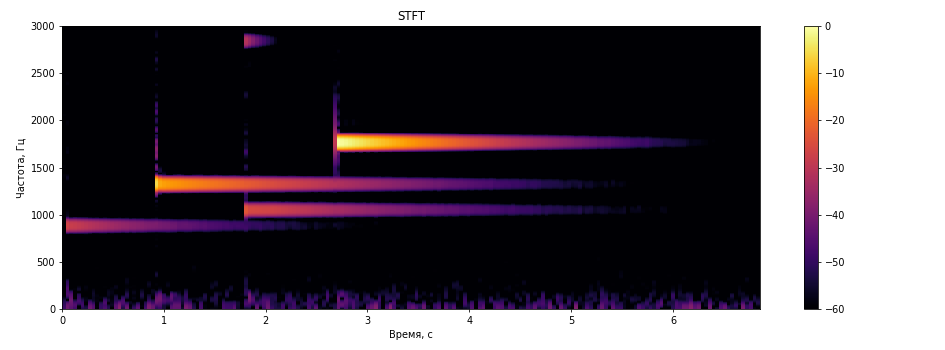

In [12]:
f, t, Zxx = signal.stft(x, fs=fs, window=('flattop'), nperseg=2000, noverlap=250, nfft=2**14)
plt.figure(figsize=[13.5, 5], dpi=70)
#plt.pcolormesh(t, f, np.abs(Zxx[:-1, :-1]), cmap=plt.get_cmap('Purples'), shading='flat')
plt.pcolormesh(t, f,  20*np.log10(np.abs(Zxx[:-1, :-1])/np.max(abs(Zxx[:-1, :-1]))), vmin=-60, cmap=plt.get_cmap('inferno'), shading='flat')
plt.colorbar()
plt.title('STFT')
plt.ylabel('Частота, Гц')
plt.xlabel('Время, с')
plt.tight_layout()
plt.ylim([0, 3000])
plt.show()


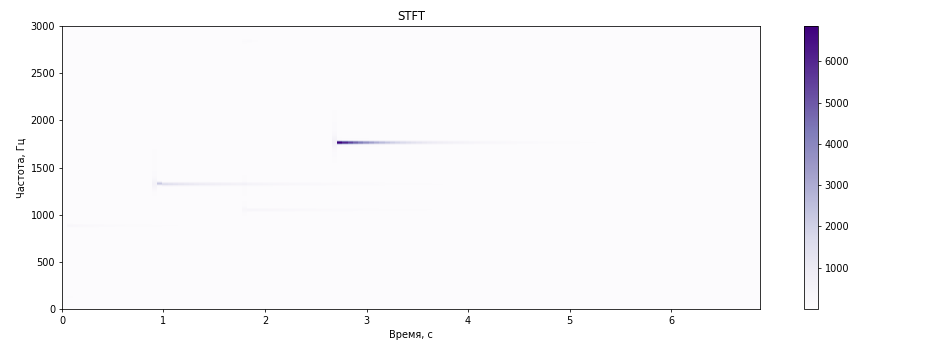

In [13]:
f, t, Zxx = signal.stft(x, fs=fs, window=('hann'), nperseg=3000, noverlap=500, nfft=2**14)
plt.figure(figsize=[13.5, 5], dpi=70)
plt.pcolormesh(t, f, np.abs(Zxx[:-1, :-1]), cmap=plt.get_cmap('Purples'), shading='flat')
#plt.pcolormesh(t, f,  20*np.log10(np.abs(Zxx[:-1, :-1])/np.max(abs(Zxx[:-1, :-1]))), vmin=-60, cmap=plt.get_cmap('inferno'), shading='flat')
plt.colorbar()
plt.title('STFT')
plt.ylabel('Частота, Гц')
plt.xlabel('Время, с')
plt.tight_layout()
plt.ylim([0, 3000])
plt.show()


## Задача 2.2. Кратковременный спектральный анализ собственного файла.

Запишите собственный wav или txt файл небольшой длины. 
Это может быть запись 
* ЛЧМ или ЧМ сигнала с осциллографа (txt),
* речи (wav),
* вокала (wav),
* музыкального инструмента (wav). 

Постройте спектрограмму сигнала и проварьируйте ее параметры. Какую информацию можно получить из анализа спектрограммы?

In [14]:
# для аудиозаписи
fs, x = wavfile.read('Nota.wav')
# Для стереозаписи выберите один канал
if len(x.shape) > 1:
    x = x[:, 0]

x, fs


(array([ -871, -1138, -1033, ...,     0,     0,     0], dtype=int16), 48000)

На аудиозаписи проигрывается нота А (ля первой октавы, 450 Гц), что соответствует спектрограмме.

Длина окна $\frac{nperseg}{f_s} = \frac{4000}{48000} \cdot 1000 = 83.3$ мс. Размер перекрытия $\frac{noverlap}{f_s} \cdot 1000 = \frac{1000}{48000} = 20.8$ мс. Единичный сдвиг окна на графике (ширина прямоугольника на временной оси) $83.3 - 20.8 = 62.5$ мс.
3. Разрешение по времени $62.5$ мс, разрешение по частоте $\frac{f_s}{N_{FTT}} = \frac{48000}{2^{12}} = 11.7$ Гц.

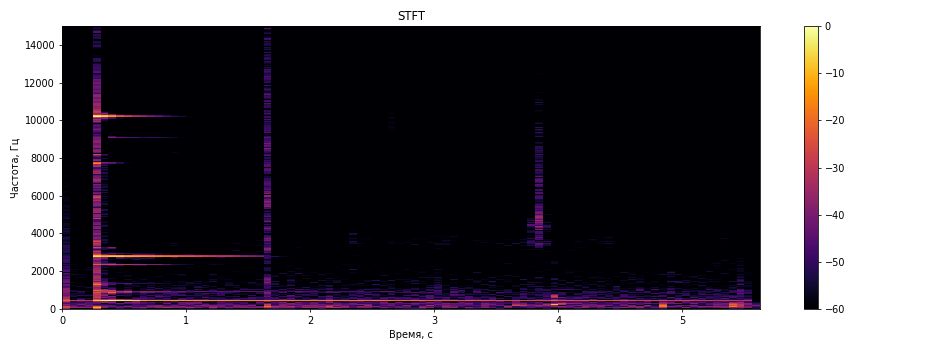

In [15]:
f, t, Zxx = signal.stft(x, fs=fs, window=('flattop'), nperseg=4000, noverlap=1000, nfft=2**12)
plt.figure(figsize=[13.5, 5], dpi=70)
#plt.pcolormesh(t, f, np.abs(Zxx[:-1, :-1]), cmap=plt.get_cmap('Purples'), shading='flat')
plt.pcolormesh(t, f,  20*np.log10(np.abs(Zxx[:-1, :-1])/np.max(abs(Zxx[:-1, :-1]))), vmin=-60, cmap=plt.get_cmap('inferno'), shading='flat')
plt.colorbar()
plt.title('STFT')
plt.ylabel('Частота, Гц')
plt.xlabel('Время, с')
plt.tight_layout()
plt.ylim([0, 15000])
plt.show()


#  Модуль 3. Периодограммные методы оценки СПМ

## Задача 3.1. Интерполяция периодограммы дополнением нулевых отсчетов (Zero Padding)

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, Гц | 10050 | 11050 | 12050 | 22050 | 20050 | 18050 | 17050 | 30050 | 31050 | 32050 | 33050 | 43050 | 40050 | 41050 | 14050 | 23050 | 25050| 28050 | 35050 | 37050 |

Записать с помощью цифрового осциллографа и генератора с частотой дискретизации 100 кГц сигнал вида sin c частотой $f_0$ (использовать диапазон 100 кГц, 1000 выборок). Построить периодограмму, для которой размерность ДПФ совпадает с длительность сигнала. Сравнить ее с периодограммой, для которой размерность ДПФ в 8 раз больше. Ответить на вопросы.

1) Какое разрешение по частоте, обусловленное сеткой частот ДПФ, у периодограммы в первом и во втором случае?

2) Как частота наблюдаемой гармонической компоненты соотносится с сеткой частот ДПФ в первом и во втором случае?

3) Почему расчет периодограммы достаточно провести для интервала частот $f \in [0; 0,5f_s]$?

1. В первом случае разрешение по частоте $\Delta f_{1} = \frac{f_s}{N_{FFT}} = \frac{100000}{1000} = 100$ Гц, во втором случае $\Delta f_{8} = \frac{f_s}{N_{FFT}} = \frac{100000}{8000} = 12.5$ Гц

2. Во втором случае более плотная сетка позволяет точнее определить положение и амплитуду спектрального максимума

3. Потому что расчет периодограммы связан с вычислением ДПФ. А спектр периодически повторяется с периодом, равным $f_s$. Причём т.к. рассматриваются вещественные сигналы, спектр симметричен относительно 0 частоты.

fs=100000


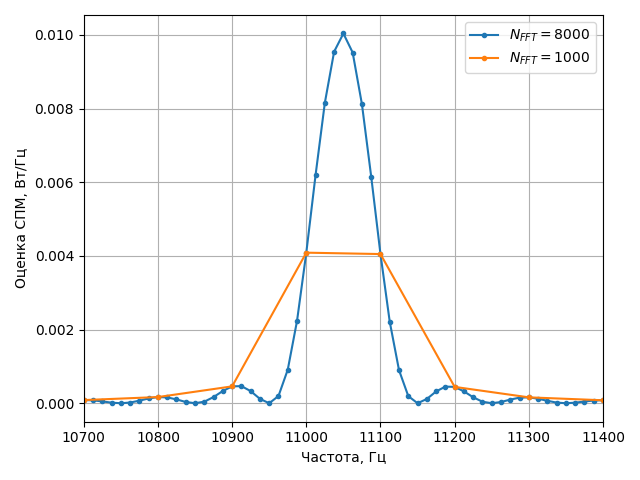

In [16]:
fs, x = oscilloscope_file_read(file='Data/gosha/gosha3.1.txt', const_level=0)
print(f"fs={fs}")
plt.figure()


nfft=8*len(x) # Размерность ДПФ для первого случая
f, Pxx_den = signal.periodogram(x, fs=fs, nfft=nfft, scaling='density')
plt.plot(f, Pxx_den/2, 'C0.-', label = "$N_{FFT} = %i$" %nfft)

nfft=len(x) # Размерность ДПФ для второго случая
f, Pxx_den = signal.periodogram(x, fs=fs, nfft=nfft, scaling='density')
plt.plot(f, Pxx_den/2, 'C1.-', label = "$N_{FFT} = %i$" %nfft)

plt.legend()
plt.xlim([0, fs/2])
plt.grid()
plt.xlabel('Частота, Гц')
plt.ylabel('Оценка СПМ, Bт/Гц')
plt.xlim((10700, 11400)) # Отображаемый диапазон частот
plt.tight_layout()
plt.show()


## Задача 3.2. Выделение синусоиды на фоне шума

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, кГц | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 40 |

Получите с помощью сумматора на резисторах сигнал суммы синусоиды с частотой $f_0$ амплитудой 0,5 В (размах 1В) и шума (установить размах 4 В). Получите 8000 последовательных выборок сигнала с частотой дискретизации 800 кГц. Постройте оценку СПМ сигнала по первым 64 выборкам и по всем 8000 выборкам. Выделяется ли спектральная компонента сигнала на фоне шума? Объясните результаты. 

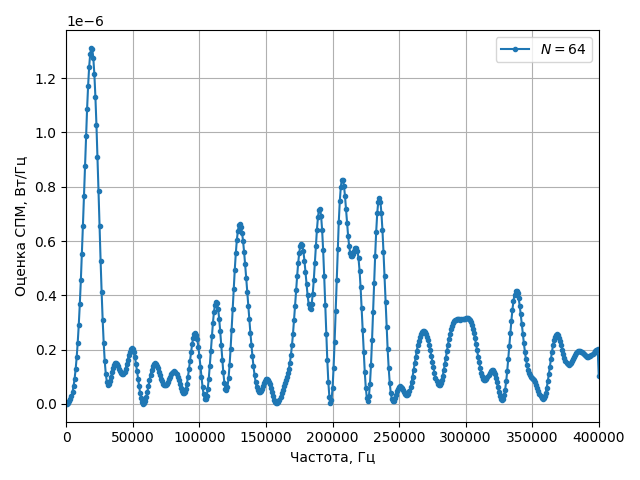

In [17]:
fs, x = oscilloscope_file_read(file='Data/gosha/32-2.txt', const_level=0)
plt.figure()

x=x[:64]
nfft=16*len(x) # Размерность ДПФ
f, Pxx_den = signal.periodogram(x, fs=fs, nfft=nfft, scaling='density')
plt.plot(f, Pxx_den/2, 'C0.-', label = "$N = %i$" %len(x))


plt.legend()
plt.xlim([0, fs/2])
plt.grid()
plt.xlabel('Частота, Гц')
plt.ylabel('Оценка СПМ, Bт/Гц')
#plt.xlim((19500, 20500)) # Отображаемый диапазон частот
plt.tight_layout()
plt.show()


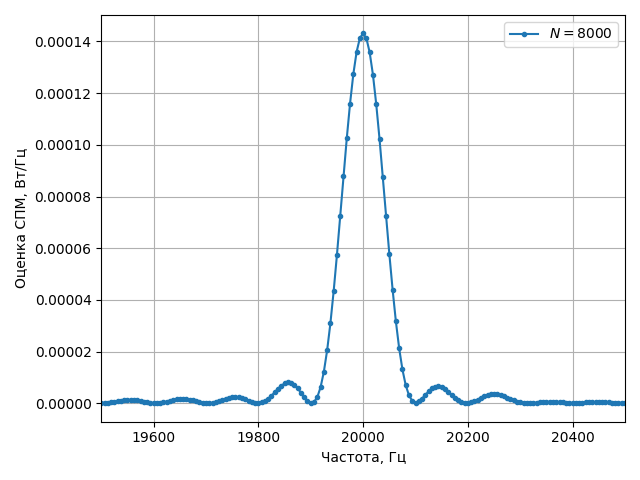

In [18]:
fs, x = oscilloscope_file_read(file='Data/gosha/32-2.txt', const_level=0)
plt.figure()

nfft=16*len(x) # Размерность ДПФ
f, Pxx_den = signal.periodogram(x, fs=fs, nfft=nfft, scaling='density')
plt.plot(f, Pxx_den/2, 'C0.-', label = "$N = %i$" %len(x))


plt.legend()
plt.xlim([0, fs/2])
plt.grid()
plt.xlabel('Частота, Гц')
plt.ylabel('Оценка СПМ, Bт/Гц')
plt.xlim((19500, 20500)) # Отображаемый диапазон частот
plt.tight_layout()
plt.show()


#  Модуль 4. Методы оценки СПМ (продолжение)

## Задача 4.1. Методы Уэлча и  Блэкмана-Тьюки

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| **Имя файла** | variant_1_ex_3_1.npy | variant_2_ex_3_1.npy | variant_3_ex_3_1.npy | variant_4_ex_3_1.npy | variant_5_ex_3_1.npy| variant_6_ex_3_1.npy | variant_1_ex_3_1.npy | variant_2_ex_3_1.npy | variant_3_ex_3_1.npy | variant_4_ex_3_1.npy | variant_5_ex_3_1.npy| variant_6_ex_3_1.npy | variant_1_ex_3_1.npy | variant_2_ex_3_1.npy | variant_3_ex_3_1.npy | variant_4_ex_3_1.npy | variant_5_ex_3_1.npy| variant_6_ex_3_1.npy | variant_1_ex_3_1.npy | variant_2_ex_3_1.npy |

По отсчетам из файла (см. таблицу) постройте оценку СПМ по методам:
* периодограмм,
* Блэкмана-Тьюки,
* модифицированных периодограмм Уэлча.

Сделайте выводы о составе процесса. Выбор параметров оценок СПМ осуществите самостоятельно. Частота дискретизации $f_s=16$ кГц. Сравните результаты.

Оцените частоту $f_1$, если известно, что случайный процесс, СПМ которого оценивается по этим выборкам, имеет вид
$$x(t)=a_1 \sin(2\pi f_1 t) + \varepsilon(t),$$
где $\varepsilon(t)$ — белый шум с нулевым математическим ожиданием.


Видно, что $f_1 = 2400$ Гц.

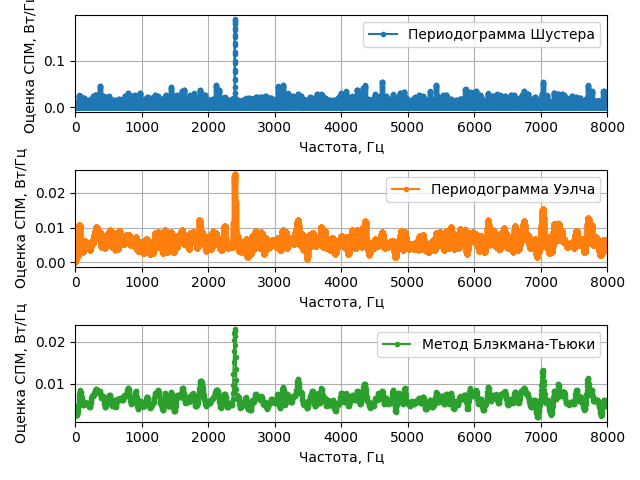

In [19]:
x = np.load('Data/dataset_lab5/variant_2_ex_3_1.npy')
fs=16_000
plt.figure()

# Периодограмма Шустера
nfft=16*len(x)
plt.subplot(3,1,1)
f, Pxx_den = signal.periodogram(x, fs=fs, nfft=nfft, scaling='density')
plt.plot(f, Pxx_den/2, 'C0.-', label = "Периодограмма Шустера")

# Периодограмма Уэлча
plt.subplot(3,1,2)
f, Pxx_den =  signal.welch(x,  fs=fs, window='boxcar', nperseg=500, noverlap=100, nfft=nfft, return_onesided=True, scaling='density')
plt.plot(f, Pxx_den/2, 'C1.-', label = "Периодограмма Уэлча")

# Метод Блэкмана-Тьюки
plt.subplot(3,1,3)
def auto_correlation(x, N1, mode='biased'):
    Rx = signal.correlate(x, x) / len(x)
    lag = np.arange(-(len(x)-1), len(x))
    return Rx[np.logical_and(lag<=N1-1, lag>=0)]

def blackman_tukey_estimator(x, window='bartlett', Nfft=None, auto_correlation_mode='biased', fs=1):
    N = len(x)
    N1 = int(np.ceil(N/10))
    if Nfft is None:
        Nfft=max(2**12, N)
    window = signal.get_window(window, 2*N1-1, fftbins=False)
    Rx = auto_correlation(x, N1, mode=auto_correlation_mode) * window[N1-1:2*N1:1]
    return fs*np.arange(Nfft)/Nfft, (2*np.fft.fft(Rx, Nfft).real - Rx[0])/fs


f, P_BT = blackman_tukey_estimator(x, window='bartlett', fs=fs)
plt.plot(f, P_BT, 'C2.-', label = "Метод Блэкмана-Тьюки")

for u in [1,2,3]:
    plt.subplot(3,1,u)
    plt.legend()
    plt.xlim([0, fs/2])
    plt.grid()
    plt.xlabel('Частота, Гц')
    plt.ylabel('Оценка СПМ, Bт/Гц')
    plt.tight_layout()
plt.show()


## Задача 4.2*. Метод Блэкмана-Тьюки для несмещенной оценки АКФ

Модифицируйте функции `auto_correlation` и `blackman_tukey_estimator` так, чтобы их можно было использовать и с несмещенной оценкой АКФ (со значениями соответствующих параметров `unbiased`). Постойте оценку СПМ по методу Блэкмана-Тьюки с несмещенной оценкой АКФ для данных из задачи 4.1. Выбор окна и размерность ДПФ осуществить самостоятельно. Сравните результат с задачей 4.1.

In [20]:
def auto_correlation(x, N1, mode):
    lag = np.arange(-(len(x)-1), len(x))
    if (mode == 'unbiased'):
        Rx = signal.correlate(x, x) / (len(x) - np.abs(lag))
    else:
        Rx = signal.correlate(x, x) / len(x)
    return Rx[np.logical_and(lag<=N1-1, lag>=0)]

def blackman_tukey_estimator(x, window='bartlett', Nfft=None, auto_correlation_mode='biased', fs=1):
    N = len(x)
    N1 = int(np.ceil(N/10))
    if Nfft is None:
        Nfft=max(2**12, N)
    window = signal.get_window(window, 2*N1-1, fftbins=False)
    Rx = auto_correlation(x, N1, mode=auto_correlation_mode) * window[N1-1:2*N1:1]
    return fs*np.arange(Nfft)/Nfft, (2*np.fft.fft(Rx, Nfft).real - Rx[0])/fs


In [21]:
x = np.load('Data/dataset_lab5/variant_2_ex_3_1.npy')
fs = 16_000
NFFT = 2**16


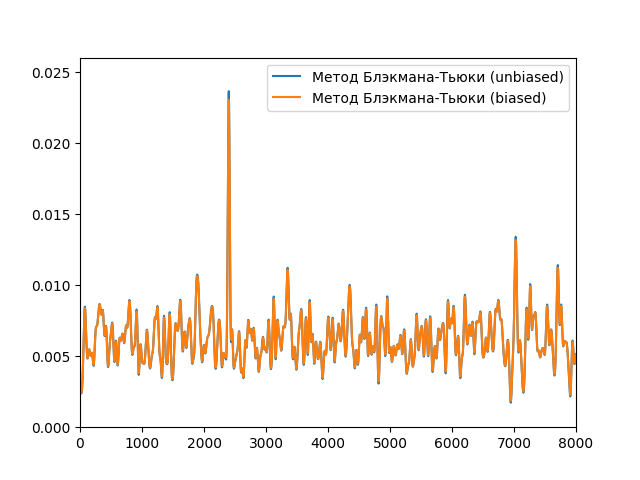

In [22]:
f1, P_BT1 = blackman_tukey_estimator(x, window='bartlett', Nfft=NFFT, auto_correlation_mode='unbiased', fs=fs)
f2, P_BT2 = blackman_tukey_estimator(x, window='bartlett', Nfft=NFFT, auto_correlation_mode='biased', fs=fs)

plt.figure()
plt.xlim([0, fs/2])
plt.ylim([0, max(max(P_BT1), max(P_BT2)) * 1.1])
plt.plot(f1, P_BT1, label = "Метод Блэкмана-Тьюки (unbiased)")
plt.plot(f2, P_BT2, label = "Метод Блэкмана-Тьюки (biased)")
plt.legend()
plt.show()


In [23]:
abs(P_BT2/P_BT1), max(abs(P_BT2 - P_BT1))/max(P_BT1) * 100


(array([1.01514832, 1.01514886, 1.01515047, ..., 1.01515315, 1.01515047,
        1.01514886]),
 2.5635158794495463)

## Задача 4.3. Оценка кросс-спектральной плотности мощности
|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, кГц | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 35 | 40 | 10 | 20 | 25 | 15 | 30 | 40 |

Получите с помощью сумматора на резисторах сигнал суммы: 

а) АМ-колебания (несущая частота $f_0$, амплитуда 2 В (размах 4 В), модуляция синусом 1 кГц) и аддитивного шума с размахом 4 В,

б) АМ-колебания (несущая частота $f_1=f_0+1\text{ кГц}$, амплитуда 2 В (размах 4 В), модуляция синусом 1 кГц) и аддитивного шума с размахом 4 В,


Получите 8000 последовательных выборок каждого из сигналов с частотой дискретизации 800 кГц. Постройте оценку взаимной СПМ процессов, а также их собственные оценки СПМ. Объясните результаты. 

In [24]:
fs, x = oscilloscope_file_read(file='Data/gosha/gosha4.3a.txt', const_level=0)
fs, y = oscilloscope_file_read(file='Data/gosha/gosha4.3b.txt', const_level=0)


In [25]:
f, Pxy = signal.csd(x, y, fs, nperseg=x.size, nfft=2**14)


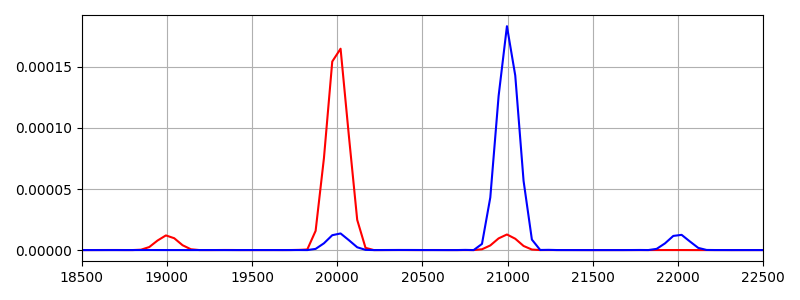

In [26]:
plt.figure(figsize=[8, 3])
f, Pxx = signal.welch(x, fs, nperseg=x.size, nfft=2**14)
f, Pyy = signal.welch(y, fs, nperseg=x.size, nfft=2**14)
f, Pxx2 = signal.csd(x, x, fs, nperseg=x.size, nfft=2**14)
f, Pyy2 = signal.csd(y, y, fs, nperseg=x.size, nfft=2**14)
plt.plot(f, np.abs(Pxx)/2, color='red')
plt.plot(f, np.abs(Pyy)/2, color='blue')
#plt.plot(f, np.abs(Pxx2)/2, color='yellow')
#plt.plot(f, np.abs(Pyy2)/2, color='green')
plt.xlim((18500, 22500))
plt.grid()
plt.tight_layout()
plt.show()


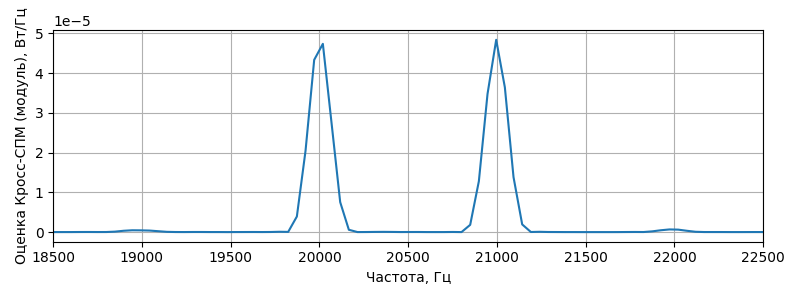

In [27]:
plt.figure(figsize=[8, 3])
#plt.semilogy(f, np.abs(Pxy))
plt.plot(f, np.abs(Pxy)/2)
plt.xlabel('Частота, Гц')
plt.ylabel('Оценка Кросс-СПМ (модуль), Bт/Гц')
plt.xlim((18500, 22500)) # Подобрать
plt.grid()
plt.tight_layout()
plt.show()


## Задача 4.4. Периодограмма Ломба-Скаргла


|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| **Имя файла** | variant_1_ex_3_4.npy | variant_2_ex_3_4.npy | variant_3_ex_3_4.npy | variant_4_ex_3_4.npy | variant_5_ex_3_4.npy| variant_6_ex_3_4.npy | variant_1_ex_3_4.npy | variant_2_ex_3_4.npy | variant_3_ex_3_4.npy | variant_4_ex_3_4.npy | variant_5_ex_3_4.npy| variant_6_ex_3_4.npy | variant_1_ex_3_4.npy | variant_2_ex_3_4.npy | variant_3_ex_3_4.npy | variant_4_ex_3_4.npy | variant_5_ex_3_4.npy| variant_6_ex_3_4.npy | variant_1_ex_3_4.npy | variant_2_ex_3_4.npy |



Постройте периодограмму Ломба-Скаргла для данных, представленных в файле, который соответствует номеру Вашего варианта.
Известно, что исходный сигнал до взятия отсчетов с неравномерным шагом имеел форму
$$x(t)=a_1 \sin(2\pi f_1 t) + a_2 \sin(2\pi f_2 t)+  \varepsilon(t),$$
где $\varepsilon(t)$ — реализация белого шума с нулевым математическим ожиданием и дисперсией $\sigma^2>0$, причем частоты $ f_1$, $ f_2 $ представлены целым числом килогерц и не превосходят 8 кГц. Оцените частоты $ f_1$ и $ f_2 $, используя периодограмму Ломба-Скаргла.

Ниже приведен пример кода, позволяющий выгрузить отчеты сигнала $x(t_i)$  (`x`) в моменты времени $t_i$ (`t`).

$f_1 = 2000$ Гц, $f_2 = 7000$ Гц.

In [28]:
x, t = np.load('Data/dataset_lab5/variant_2_ex_3_4.npy')


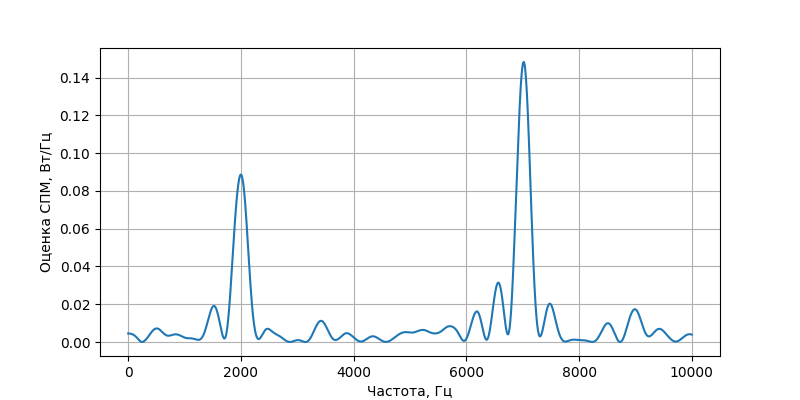

In [29]:
w=np.linspace(1e-10, 10000, 2**12)*2*np.pi
pgram = signal.lombscargle(t, x, freqs=w, normalize=True)

plt.figure(figsize=[8, 4])
plt.plot(w/(2*np.pi), pgram)
plt.xlabel('Частота, Гц')
plt.ylabel('Оценка СПМ, Bт/Гц')
plt.grid()
plt.show()


## Задача 4.5*. Переменные звезды. 

Переменными называют звезды, у которых можно зафиксировать измененние видимой звёздной величины (блеска). Причины перемены блеска могут быть обусловлены различными физическими процессами. Для ряда объектов изменения блеска периодичны. 

Используя данные из файла ```LINEAR_dataset.json``` (Lincoln Near Earth Asteroid Research project), проведите анализ переменности для одной из звезд. Постройте график зависимости блеска от времени и вычислите период изменения блекса с помощью метода Ломба-Скаргала. Cопоставьте полученный результат с эталонным значением из каталога. Объяснить различие, если оно есть. На основе найденного периода сформируйте фазовую кривую.

In [30]:
import json
with open('LINEAR_dataset.json', 'r', encoding='utf-8') as f:
    json_dict = json.load(f)

familyname = "Багров"
keys = list(json_dict.keys())
example = json_dict[keys[sum(map(ord, familyname)) % len(keys)]]

# вывод табличных параметров
example['params']


{'ra': 207.355225,
 'period': 0.6159619710032036,
 'dec': 39.589951,
 'ug': 1.315,
 'gi': 0.354,
 'iK': 1.387,
 'JK': 0.173,
 'logP': -0.2104461,
 'Ampl': 0.74,
 'skew': -0.55,
 'kurt': -0.498,
 'magMed': 14.29,
 'nObs': 246,
 'LCtype': 1,
 'LINEARobjectID': 10022663}

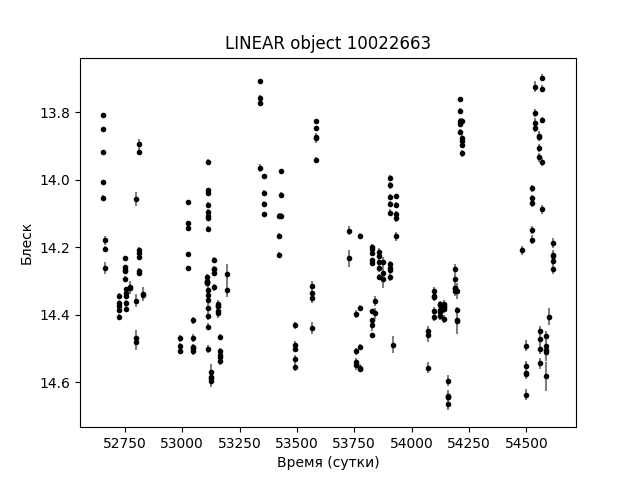

In [31]:
fig, ax = plt.subplots()
ax.errorbar(example['light_curve']['t'], example['light_curve']['mag'], example['light_curve']['dmag'], fmt='.k', ecolor='gray')
ax.set(xlabel='Время (сутки)', ylabel='Блеск',
       title='LINEAR object %d' % example['params']['LINEARobjectID'])
ax.invert_yaxis();


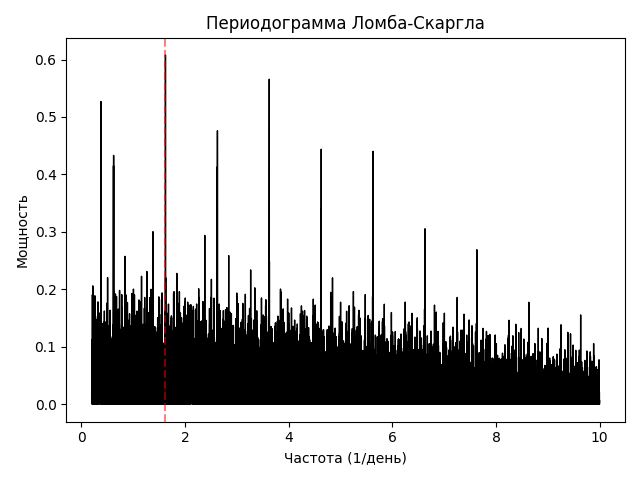

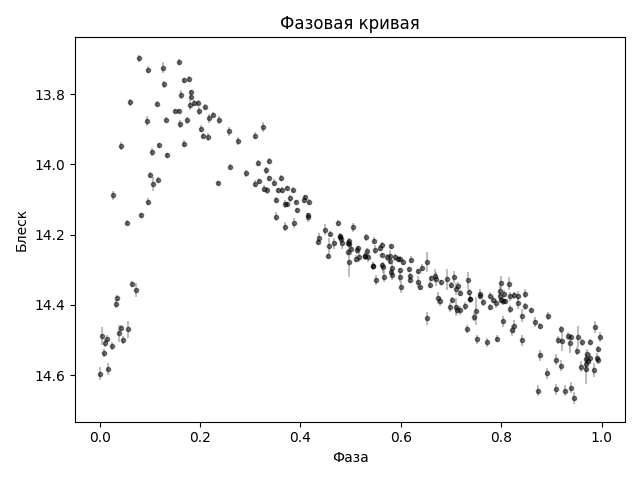

Вычисленный период: 0.61598 дней
Табличный период: 0.61596 дней


In [32]:
ls = LombScargle(example['light_curve']['t'], example['light_curve']['mag'], fit_mean=True, center_data=True)
frequency, power = ls.autopower(minimum_frequency=0.2, maximum_frequency=10)

# Поиск периода
best_frequency = frequency[np.argmax(power)]
period = 1 / best_frequency

# Периодограмма Ломба-Скаргла
plt.figure()
plt.plot(frequency, power, color='black', lw=1)
plt.gca().set(xlabel='Частота (1/день)', ylabel='Мощность', title='Периодограмма Ломба-Скаргла')
plt.axvline(best_frequency, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Фазовая кривая
# Фаза = (время / период) % 1
plt.figure()
phase = (example['light_curve']['t'] / period) % 1
plt.errorbar(phase, example['light_curve']['mag'], example['light_curve']['dmag'], fmt='.k', ecolor='gray', alpha=0.5)
plt.gca().set(xlabel='Фаза', ylabel='Блеск',
          title=f'Фазовая кривая')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Вычисленный период: {period:.5f} дней")
print(f"Табличный период: {example['params']['period']:.5f} дней")
